## Entregable 4: Análisis Exploratorio, Limpieza y Transformación de Datos de Ventas con Python, Pandas y Jupyter Notebooks

**Bootcamp Análisis de Datos Nivel Intermedio**    
**Estudiante:** Karen Daniela Urbano Trujillo  C.C. 1000143241

**Fecha:** 17 Octubre 2025  
**Archivo:** `Entregable_Procesamiento_Datos.ipynb`

---

Este notebook documenta el proceso completo de análisis exploratorio, limpieza, transformación y visualización de un conjunto de datos de ventas utilizando Python, Pandas, Matplotlib y Seaborn. Se incluyen capturas de pantalla, reflexiones.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
print("Librerías importadas correctamente.")

Librerías importadas correctamente.


In [2]:
#Crear carpeta de docs
mkdir docs

In [3]:
#Exportar Notebook en formato html guardado en inde.html para crear github page
!jupyter nbconvert Entregable_Procesamiento_Datos.ipynb --to html --output docs/index

[NbConvertApp] Converting notebook Entregable_Procesamiento_Datos.ipynb to html
[NbConvertApp] WARNING | Alternative text is missing on 3 image(s).
[NbConvertApp] Writing 414430 bytes to docs\index.html


In [2]:
#cargar el csv ventas_tienda
df_ventas = pd.read_csv('C:/Users/karen/anaconda_projects/Entregable_Procesamiento_Datos/ventas_tienda.csv') #pd.read_csv(ventas_tienda.csv.) 

In [3]:
#Exploración inicial
print("Primeras 5 filas del DataFrame:")
print(df_ventas.head())

print("\nInformación general del DataFrame:")
df_ventas.info()

print("\nEstadísticas descriptivas del DataFrame:")
print(df_ventas.describe(include='all'))

Primeras 5 filas del DataFrame:
   ID_Venta       Fecha Producto_ID    Categoria  Cantidad  Precio_Unitario  \
0         1  2023-01-15        P101  Electronica       2.0           1200.0   
1         2  2023-01-16        P102         Ropa       3.0             25.5   
2         3  2023-01-16        P103        Hogar       1.0             75.0   
3         4  2023-01-17        P101  Electronica       1.0           1200.0   
4         5  2023-01-18        P104       Libros       NaN             15.0   

  Cliente_ID Region   
0       C001  Norte   
1       C002    Sur   
2       C003   Este   
3       C001  Norte   
4       C004  Oeste   

Información general del DataFrame:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15 entries, 0 to 14
Data columns (total 8 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   ID_Venta         15 non-null     int64  
 1   Fecha            15 non-null     object 
 2   Producto_ID      15 non-null

### Captura 1: Exploración inicial del DataFrame
![Captura 1](Capturas/CAPTURARPANTALLA_1__Salida_de_df_ventas.png)

In [4]:
print("\nValores faltantes por columna ANTES de la imputación:")
print(df_ventas.isnull().sum())

# Imputar 'Cantidad' con la mediana
mediana_cantidad = df_ventas['Cantidad'].median()
df_ventas['Cantidad'] = df_ventas['Cantidad'].fillna(mediana_cantidad)
print(f"\nValores NaN en 'Cantidad' imputados con la mediana: {mediana_cantidad}")

# Imputar 'Precio Unitario' con la media si es necesario
if df_ventas['Precio_Unitario'].isnull().any():
    media_precio = df_ventas['Precio_Unitario'].mean()
    df_ventas['Precio_Unitario'].fillna(media_precio, inplace=True)
    print(f"Valores NaN en 'Precio Unitario' imputados con la media: {media_precio}")

print("\nValores faltantes por columna DESPUÉS de la imputación:")
print(df_ventas.isnull().sum())


Valores faltantes por columna ANTES de la imputación:
ID_Venta           0
Fecha              0
Producto_ID        0
Categoria          0
Cantidad           2
Precio_Unitario    0
Cliente_ID         0
Region             0
dtype: int64

Valores NaN en 'Cantidad' imputados con la mediana: 2.0

Valores faltantes por columna DESPUÉS de la imputación:
ID_Venta           0
Fecha              0
Producto_ID        0
Categoria          0
Cantidad           0
Precio_Unitario    0
Cliente_ID         0
Region             0
dtype: int64


In [5]:
#Duplicados
duplicados_antes = df_ventas.duplicated().sum()
print(f"\nNúmero de filas duplicadas ANTES de eliminar: {duplicados_antes}")
df_ventas.drop_duplicates(inplace=True)
duplicados_despues = df_ventas.duplicated().sum()
print(f"Número de filas duplicadas DESPUÉS de eliminar: {duplicados_despues}")


Número de filas duplicadas ANTES de eliminar: 0
Número de filas duplicadas DESPUÉS de eliminar: 0


### Captura 2: Verificación de valores faltantes y duplicados
![Captura 2](Capturas/CAPTURARPANTALLA_2_Salida_de_la_verificación_Faltantes_Duplicados.png)

In [6]:
#Corrección de tipos de datos
df_ventas['Fecha'] = pd.to_datetime(df_ventas['Fecha'])
df_ventas['Cantidad'] = pd.to_numeric(df_ventas['Cantidad'])
df_ventas['Precio_Unitario'] = pd.to_numeric(df_ventas['Precio_Unitario'])

print("\nTipos de datos después de la conversión:")
df_ventas.info()


Tipos de datos después de la conversión:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15 entries, 0 to 14
Data columns (total 8 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   ID_Venta         15 non-null     int64         
 1   Fecha            15 non-null     datetime64[ns]
 2   Producto_ID      15 non-null     object        
 3   Categoria        15 non-null     object        
 4   Cantidad         15 non-null     float64       
 5   Precio_Unitario  15 non-null     float64       
 6   Cliente_ID       15 non-null     object        
 7   Region           15 non-null     object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 1.1+ KB


In [7]:
#Estandarización de texto
print("\nValores únicos en 'Categoria' ANTES de estandarizar:") 
print(df_ventas['Categoria'].unique())
df_ventas['Categoria'] = df_ventas['Categoria'].str.capitalize() 
print("\nValores únicos en 'Categoria' DESPUÉS de estandarizar:")
print(df_ventas['Categoria'].unique())



Valores únicos en 'Categoria' ANTES de estandarizar:
['Electronica' 'Ropa' 'Hogar' 'Libros' 'Juguetes' 'Alimentos'
 'electronica']

Valores únicos en 'Categoria' DESPUÉS de estandarizar:
['Electronica' 'Ropa' 'Hogar' 'Libros' 'Juguetes' 'Alimentos']


### Captura 3: Tipos de datos y estandarización de 'Categoria'
![Captura 3](Capturas/CAPTURARPANTALLA_3_Salida_de_df_ventas_info_categoria.png)

In [8]:
# Crear columna Ingreso_Total: Multiplica Cantidad por Precio_Unitario
df_ventas['Ingreso_Total'] = df_ventas['Cantidad'] * df_ventas['Precio_Unitario']
print("\nDataFrame con la nueva columna 'Ingreso_Total':")
print(df_ventas.head())



DataFrame con la nueva columna 'Ingreso_Total':
   ID_Venta      Fecha Producto_ID    Categoria  Cantidad  Precio_Unitario  \
0         1 2023-01-15        P101  Electronica       2.0           1200.0   
1         2 2023-01-16        P102         Ropa       3.0             25.5   
2         3 2023-01-16        P103        Hogar       1.0             75.0   
3         4 2023-01-17        P101  Electronica       1.0           1200.0   
4         5 2023-01-18        P104       Libros       2.0             15.0   

  Cliente_ID Region   Ingreso_Total  
0       C001  Norte          2400.0  
1       C002    Sur            76.5  
2       C003   Este            75.0  
3       C001  Norte          1200.0  
4       C004  Oeste            30.0  


In [9]:
# Extraer componentes de fecha
df_ventas['Año'] = df_ventas['Fecha'].dt.year
df_ventas['Mes'] = df_ventas['Fecha'].dt.month
df_ventas['Dia_Semana'] = df_ventas['Fecha'].dt.day_name()

print("\nDataFrame con columnas de fecha extraídas:")
print(df_ventas[['Fecha', 'Año', 'Mes', 'Dia_Semana']].head())



DataFrame con columnas de fecha extraídas:
       Fecha   Año  Mes Dia_Semana
0 2023-01-15  2023    1     Sunday
1 2023-01-16  2023    1     Monday
2 2023-01-16  2023    1     Monday
3 2023-01-17  2023    1    Tuesday
4 2023-01-18  2023    1  Wednesday


In [10]:
print(df_ventas.head())

   ID_Venta      Fecha Producto_ID    Categoria  Cantidad  Precio_Unitario  \
0         1 2023-01-15        P101  Electronica       2.0           1200.0   
1         2 2023-01-16        P102         Ropa       3.0             25.5   
2         3 2023-01-16        P103        Hogar       1.0             75.0   
3         4 2023-01-17        P101  Electronica       1.0           1200.0   
4         5 2023-01-18        P104       Libros       2.0             15.0   

  Cliente_ID Region   Ingreso_Total   Año  Mes Dia_Semana  
0       C001  Norte          2400.0  2023    1     Sunday  
1       C002    Sur            76.5  2023    1     Monday  
2       C003   Este            75.0  2023    1     Monday  
3       C001  Norte          1200.0  2023    1    Tuesday  
4       C004  Oeste            30.0  2023    1  Wednesday  


### Captura 4: Nuevas columnas creadas
![Captura 4](Capturas/CAPTURARPANTALLA_4_df_ventas_head.png)

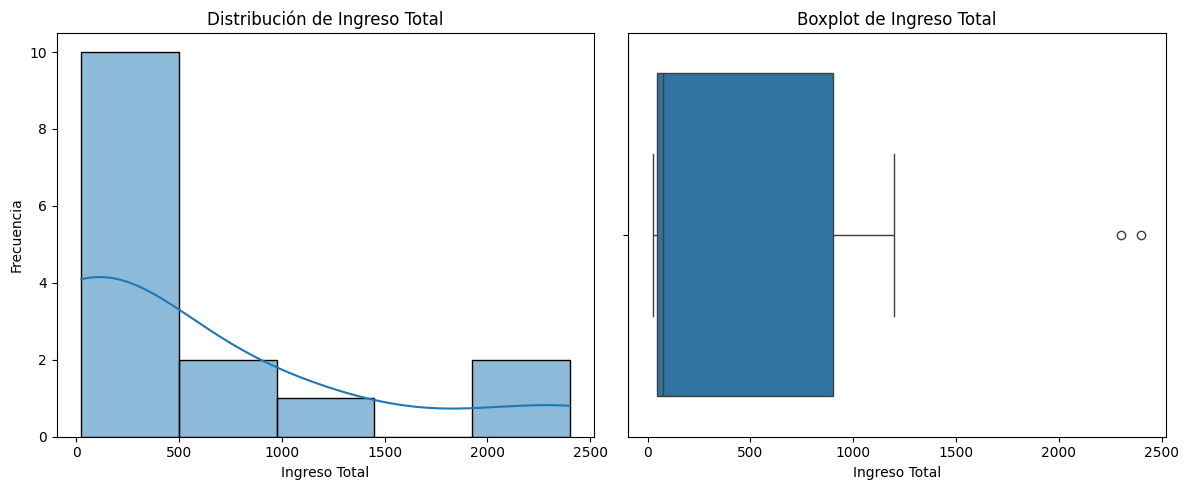

In [11]:
# Análisis Exploratorio con Visualizaciones
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.histplot(df_ventas['Ingreso_Total'], kde=True)
plt.title('Distribución de Ingreso Total')
plt.xlabel('Ingreso Total')
plt.ylabel('Frecuencia')

plt.subplot(1, 2, 2)
sns.boxplot(x=df_ventas['Ingreso_Total'])
plt.title('Boxplot de Ingreso Total')
plt.xlabel('Ingreso Total')

plt.tight_layout()
plt.show()



### Captura 5: Histograma y Boxplot de Ingreso_Total
![Captura 5](Capturas/CAPTURARPANTALLA_5_Histograma_y_Boxplot_de_Ingreso_TotaL.png)

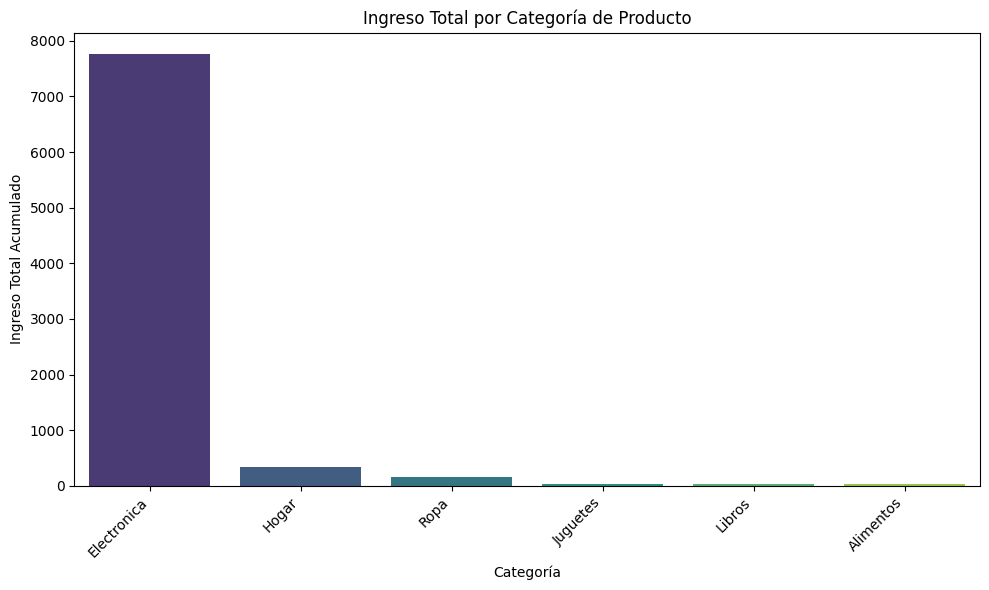

In [12]:
# 2.	Ingresos por Categoria: Crea un gráfico de barras mostrando el ingreso total sumado por categoría
ingresos_por_categoria = df_ventas.groupby('Categoria')['Ingreso_Total'].sum().sort_values(ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x=ingresos_por_categoria.index, y=ingresos_por_categoria.values, hue=ingresos_por_categoria.index, palette='viridis', legend=False)
plt.title('Ingreso Total por Categoría de Producto')
plt.xlabel('Categoría')
plt.ylabel('Ingreso Total Acumulado')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


### Captura 6: Gráfico de barras por categoría
![Captura 6](Capturas/CAPTURARPANTALLA_6_Gráfico_de_barras_de_Ingreso_Total_por_Categoría.png)

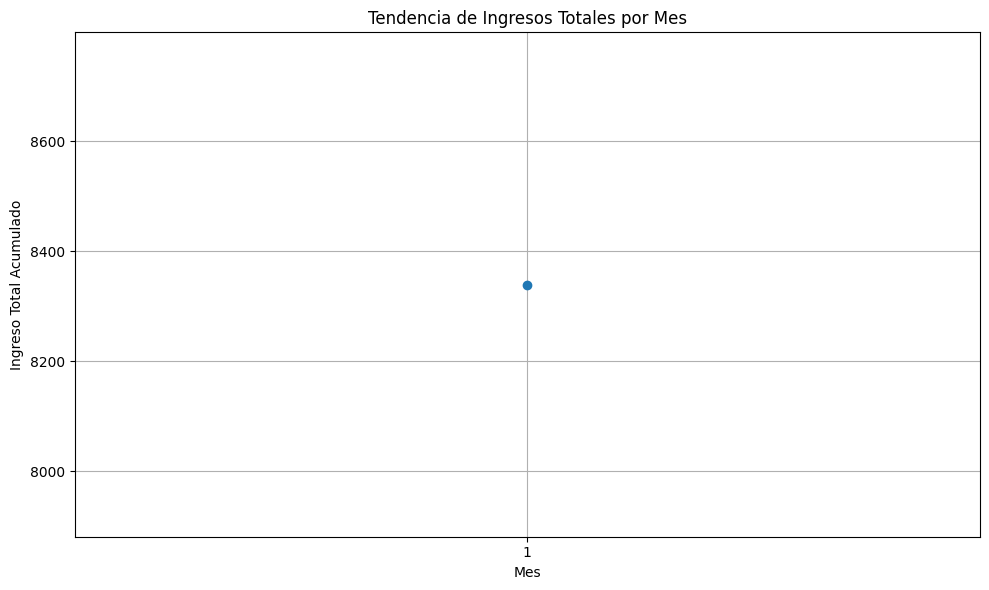

In [13]:
#3.	Ingresos a lo largo del tiempo (por Mes): Crea un gráfico de líneas mostrando la tendencia de Ingreso_TotaL por mes
ingresos_por_mes = df_ventas.groupby('Mes')['Ingreso_Total'].sum()
plt.figure(figsize=(10, 6))
ingresos_por_mes.plot(kind='line', marker='o')
plt.title('Tendencia de Ingresos Totales por Mes')
plt.xlabel('Mes')
plt.ylabel('Ingreso Total Acumulado')
plt.xticks(ingresos_por_mes.index)
plt.grid(True)
plt.tight_layout()
plt.show()




### Captura 7: Gráfico de línea por mes
![Captura 7](Capturas/CAPTURARPANTALLA_7_Gráfico_de_líneas_de_Ingreso_Total_por_Mes.png)

# Preguntas de Reflexión

## 1. Manejo de Nulos
Se eligió la mediana para imputar los valores faltantes en la columna `Cantidad` porque es menos sensible a valores extremos que la media. Esto ayuda a mantener la distribución original sin distorsionar el análisis. En casos donde los valores faltantes son pocos y aleatorios, o cuando no se puede imputar de forma confiable, puede ser preferible eliminar esas filas para evitar introducir sesgos.

## 2. Tipos de Datos
Convertir la columna `Fecha` al tipo `datetime` es fundamental porque permite realizar operaciones temporales como extraer el año, mes, día de la semana, calcular diferencias entre fechas, agrupar por periodos y generar visualizaciones cronológicas. Esta conversión habilita análisis más profundos y precisos relacionados con el comportamiento de ventas a lo largo del tiempo.

## 3. Feature Engineering
Una característica útil adicional podría ser una columna `Tipo_Compra`, que clasifique las ventas como "Alta", "Media" o "Baja" según el valor de `Ingreso_Total`. Esto permitiría segmentar transacciones y analizar patrones de comportamiento por tipo de compra, facilitando decisiones estratégicas como promociones o segmentación de clientes.

## 4. Visualizaciones y Outliers
El boxplot de `Ingreso_Total` muestra posibles outliers, especialmente en transacciones de alto valor. Antes de tratarlos, es importante verificar si corresponden a errores o a compras legítimas. Si son válidos, deben conservarse para reflejar la realidad del negocio. Si son errores, podrían corregirse o eliminarse, documentando siempre el criterio utilizado.

## 5. Próximos Pasos
Para continuar el análisis, se podrían realizar los siguientes pasos:
- Agrupar ventas por cliente para identificar patrones de fidelidad o frecuencia.
- Analizar el comportamiento por región para detectar oportunidades geográficas.
- Preparar los datos para modelos predictivos, como estimación de demanda o segmentación de clientes.
- Detectar productos más rentables.

